In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

path = "../dataset/Sales - Marketing customer dataset.csv"
data = pd.read_csv(path)

data.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


#Soal Pertama : 1. Data Understanding & EDA (Konsep EDA)

In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

In [3]:
data.describe()

,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,13800.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,17500.500000,35.203913,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,1.995600,0.147667,2.981333,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
std,4330.271354,10.334384,0.460197,3.892704,2.991499,1.479846,0.290108,0.144689,467.050070,24.746203,0.499986,1.421214,0.354781,1.720537,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192
min,10001.000000,-4.000000,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,28.000000,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,35.000000,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,42.000000,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,95.000000,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000


##Fitur Kategorikal

In [4]:
categorical_features = data.select_dtypes(include='object').columns.tolist()
print("Categorical Features:", categorical_features)

Categorical Features: ['gender', 'country', 'city', 'signup_date', 'last_purchase_date', 'acquisition_channel', 'device_type', 'subscription_type', 'coupon_code', 'payment_method']


In [5]:
for col in categorical_features:
    print(f"\nFitur: '{col}'")
    total_unique = data[col].nunique()
    print(f"Jumlah nilai unik (Total Unique): {total_unique}")

    print(f"Daftar nilai unik dan jumlahnya:")
    print(data[col].value_counts())


Fitur: 'gender'
Jumlah nilai unik (Total Unique): 3
Daftar nilai unik dan jumlahnya:
gender
Male      6844
Female    6686
Other      732
Name: count, dtype: int64

Fitur: 'country'
Jumlah nilai unik (Total Unique): 5
Daftar nilai unik dan jumlahnya:
country
Germany       3072
India         3014
Bangladesh    2984
USA           2975
UK            2955
Name: count, dtype: int64

Fitur: 'city'
Jumlah nilai unik (Total Unique): 7
Daftar nilai unik dan jumlahnya:
city
London      2236
Mumbai      2184
Dhaka       2178
New York    2135
Delhi       2128
Berlin      2075
Hamburg     2064
Name: count, dtype: int64

Fitur: 'signup_date'
Jumlah nilai unik (Total Unique): 1000
Daftar nilai unik dan jumlahnya:
signup_date
2024-09-20 00:00:00    29
2022-06-03 00:00:00    28
2024-05-11 00:00:00    27
2024-02-10 00:00:00    27
2024-02-05 00:00:00    26
                       ..
2023-06-30 00:00:00     6
2024-03-14 00:00:00     6
2023-02-05 00:00:00     5
2024-03-28 00:00:00     5
2024-08-23 00:00:00 

C:\Users\hanao\AppData\Local\Temp\ipykernel_4804\3219893425.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=feature, palette='viridis', order=data[feature].value_counts().index)


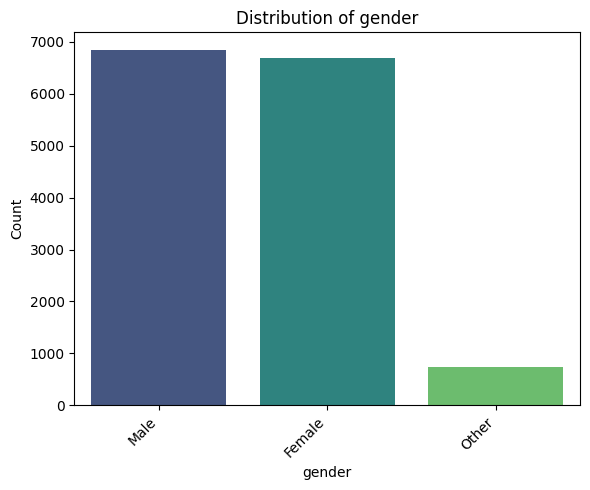

C:\Users\hanao\AppData\Local\Temp\ipykernel_4804\3219893425.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=feature, palette='viridis', order=data[feature].value_counts().index)


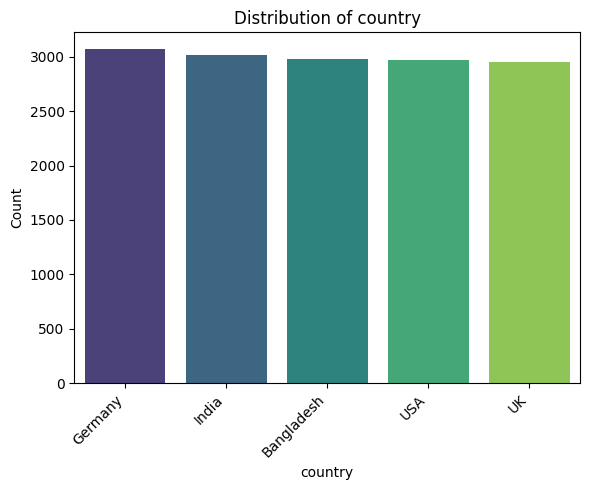

C:\Users\hanao\AppData\Local\Temp\ipykernel_4804\3219893425.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=feature, palette='viridis', order=data[feature].value_counts().index)


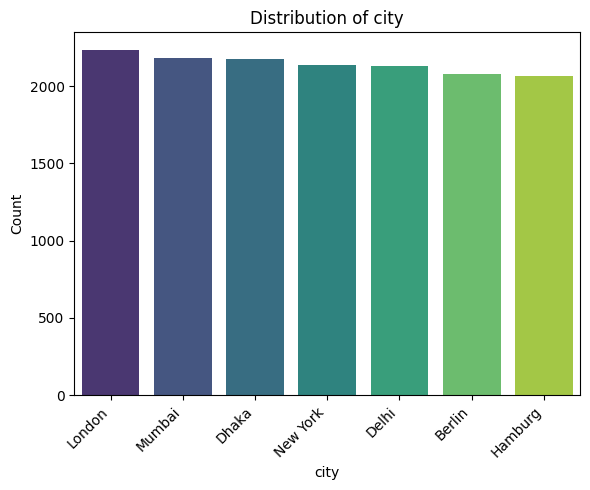

C:\Users\hanao\AppData\Local\Temp\ipykernel_4804\3219893425.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=feature, palette='viridis', order=data[feature].value_counts().index)


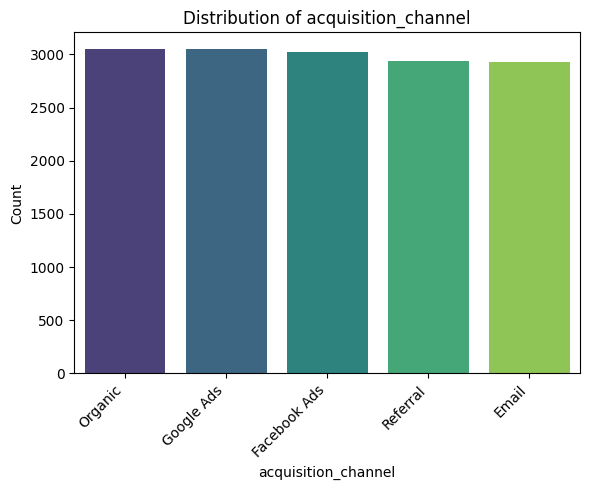

C:\Users\hanao\AppData\Local\Temp\ipykernel_4804\3219893425.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=feature, palette='viridis', order=data[feature].value_counts().index)


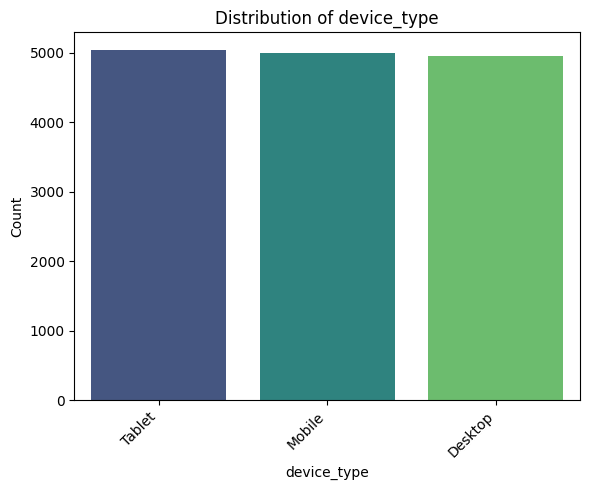

C:\Users\hanao\AppData\Local\Temp\ipykernel_4804\3219893425.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=feature, palette='viridis', order=data[feature].value_counts().index)


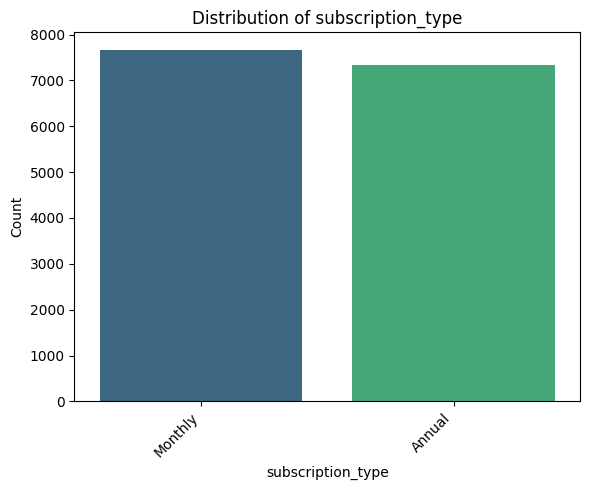

C:\Users\hanao\AppData\Local\Temp\ipykernel_4804\3219893425.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=feature, palette='viridis', order=data[feature].value_counts().index)


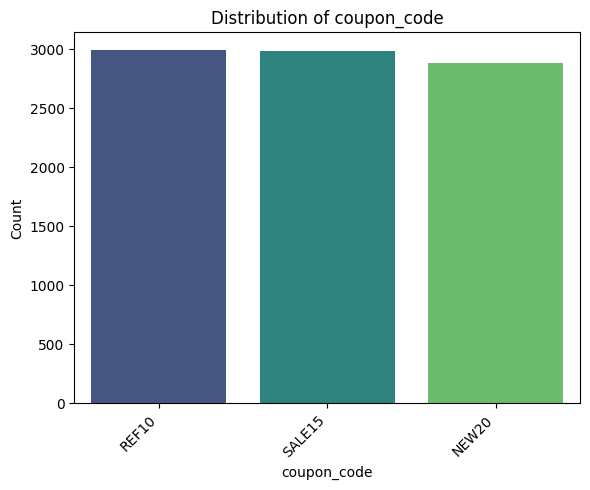

C:\Users\hanao\AppData\Local\Temp\ipykernel_4804\3219893425.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=feature, palette='viridis', order=data[feature].value_counts().index)


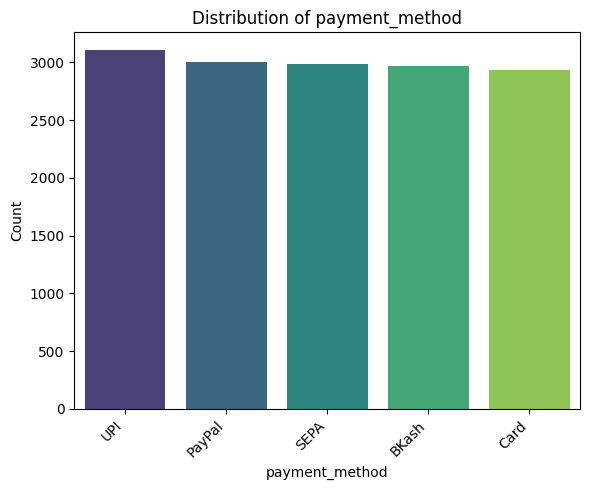

In [6]:
categorical_features_to_plot = [
    'gender', 'country', 'city', 'acquisition_channel',
    'device_type', 'subscription_type', 'coupon_code', 'payment_method'
]

for feature in categorical_features_to_plot:
    plt.figure(figsize=(6, 5))
    sns.countplot(data=data, x=feature, palette='viridis', order=data[feature].value_counts().index)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

##Fitur Ordinal

In [7]:
ordinal_features = [
    'satisfaction_score',
    'nps_score',
]

In [8]:
for col in ordinal_features:
    print(f"\n🔹 {col}")
    print(data[col].value_counts().sort_index())


🔹 satisfaction_score
satisfaction_score
1.0     753
2.0    1455
3.0    3739
4.0    5323
5.0    3028
Name: count, dtype: int64

🔹 nps_score
nps_score
0     1370
1     1346
2     1417
3     1402
4     1388
5     1303
6     1386
7     1350
8     1356
9     1357
10    1325
Name: count, dtype: int64


C:\Users\hanao\AppData\Local\Temp\ipykernel_4804\252412215.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, palette='viridis', order=sorted(data[col].unique()))


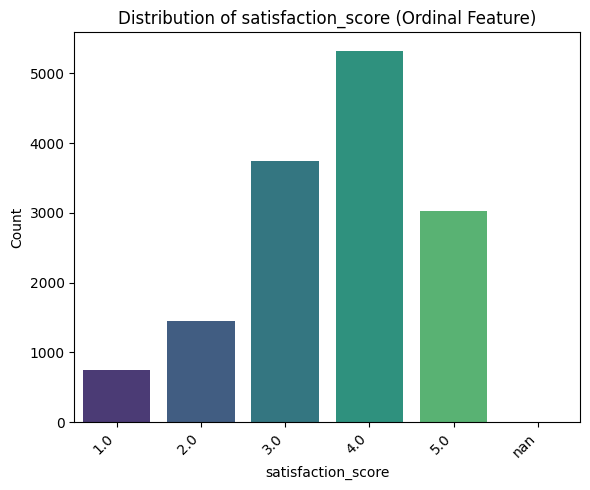

C:\Users\hanao\AppData\Local\Temp\ipykernel_4804\252412215.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, palette='viridis', order=sorted(data[col].unique()))


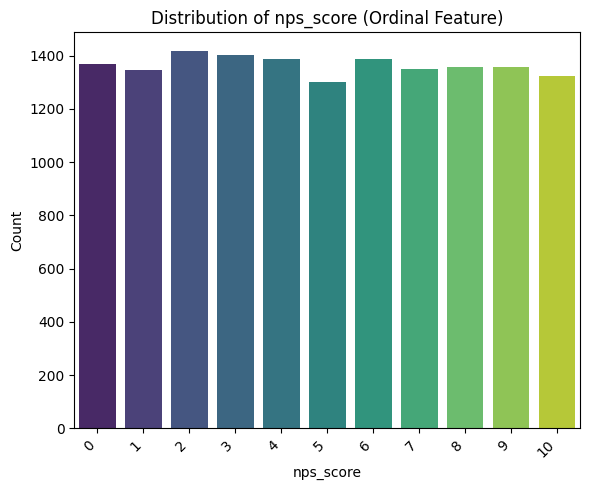

In [9]:
for col in ordinal_features:
    plt.figure(figsize=(6, 5))
    sns.countplot(data=data, x=col, palette='viridis', order=sorted(data[col].unique()))
    plt.title(f'Distribution of {col} (Ordinal Feature)')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

##Fitur Biner

In [10]:
binary_features = [
    'is_premium_user',
    'discount_used',
    'refund_requested'
]

In [11]:
for col in binary_features:
    print(f"\nFitur: '{col}'")
    print(f"Jumlah nilai unik (Total Unique): {data[col].nunique()}")
    print("Daftar nilai unik dan jumlahnya:")
    print(data[col].value_counts())


Fitur: 'is_premium_user'
Jumlah nilai unik (Total Unique): 2
Daftar nilai unik dan jumlahnya:
is_premium_user
0    10433
1     4567
Name: count, dtype: int64

Fitur: 'discount_used'
Jumlah nilai unik (Total Unique): 2
Daftar nilai unik dan jumlahnya:
discount_used
0    7583
1    7417
Name: count, dtype: int64

Fitur: 'refund_requested'
Jumlah nilai unik (Total Unique): 2
Daftar nilai unik dan jumlahnya:
refund_requested
0    12785
1     2215
Name: count, dtype: int64


C:\Users\hanao\AppData\Local\Temp\ipykernel_4804\4137328714.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, palette='viridis')


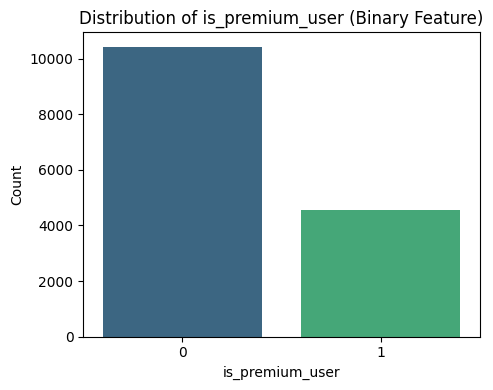

C:\Users\hanao\AppData\Local\Temp\ipykernel_4804\4137328714.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, palette='viridis')


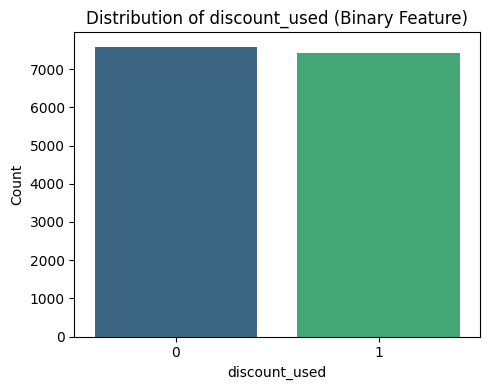

C:\Users\hanao\AppData\Local\Temp\ipykernel_4804\4137328714.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, palette='viridis')


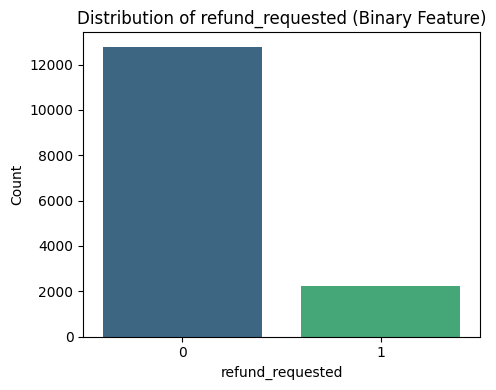

In [12]:
for col in binary_features:
    plt.figure(figsize=(5, 4))
    sns.countplot(data=data, x=col, palette='viridis')
    plt.title(f'Distribution of {col} (Binary Feature)')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

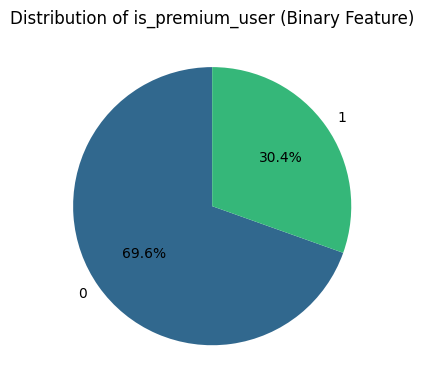

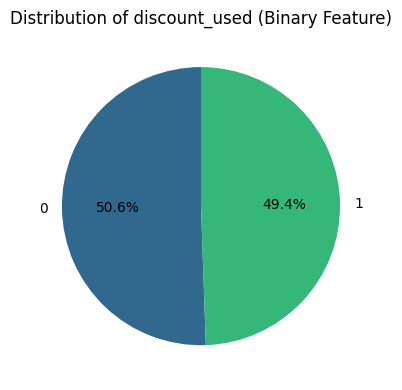

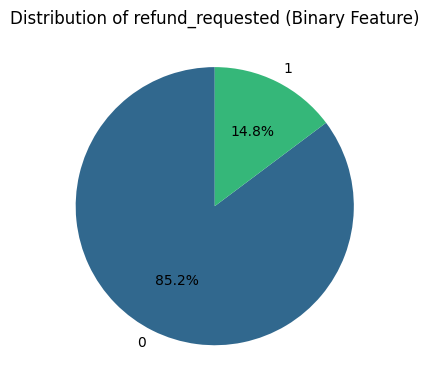

In [13]:
for col in binary_features:
    plt.figure(figsize=(4, 4))
    counts = data[col].value_counts()
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(counts)))
    plt.title(f'Distribution of {col} (Binary Feature)')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

##Fitur numerik

In [14]:
numerical_features = [
    'age',
    'total_visits',
    'avg_session_time',
    'pages_per_session',
    'email_open_rate',
    'email_click_rate',
    'total_spent',
    'avg_order_value',
    'support_tickets',
    'delivery_delay_days',
    'marketing_spend_per_user',
    'lifetime_value',
    'last_3_month_purchase_freq'
]

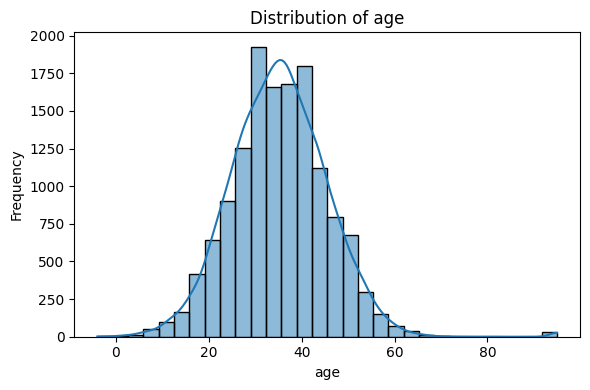

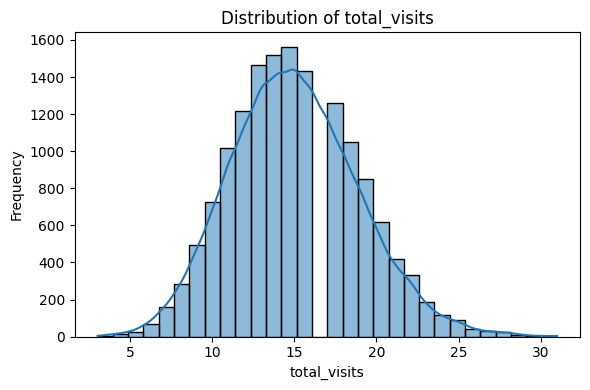

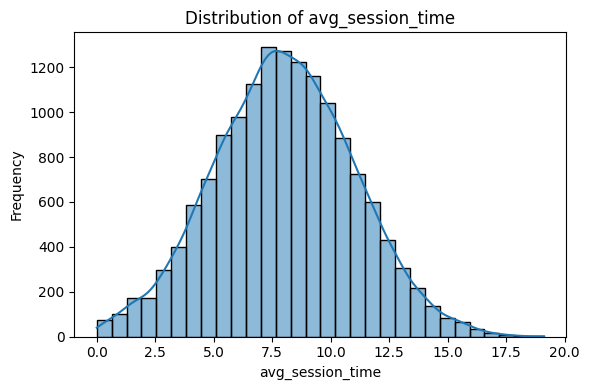

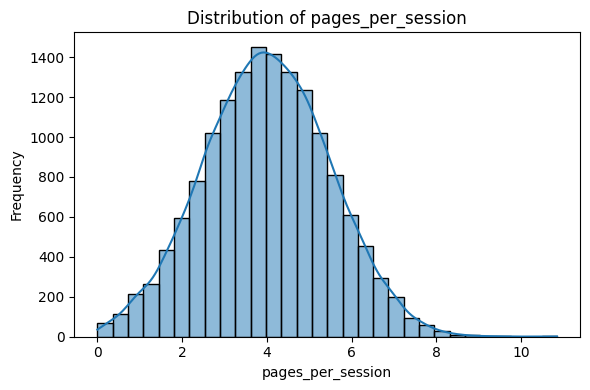

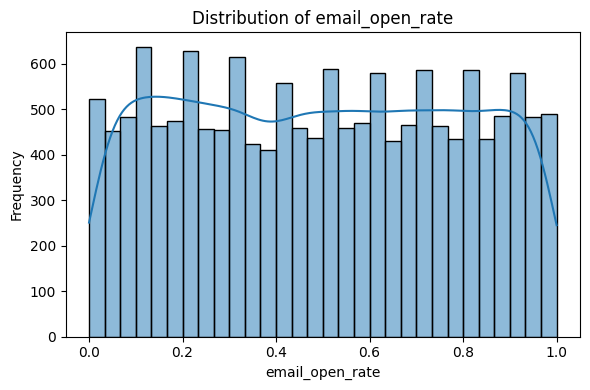

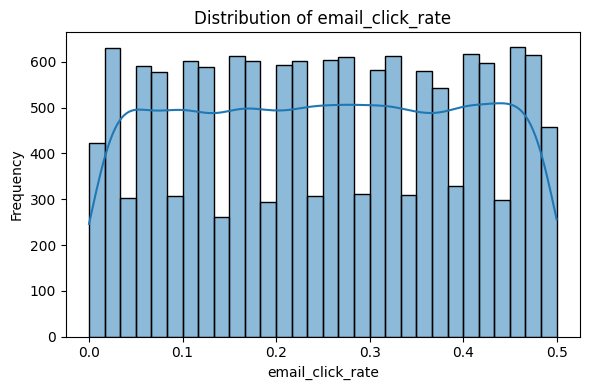

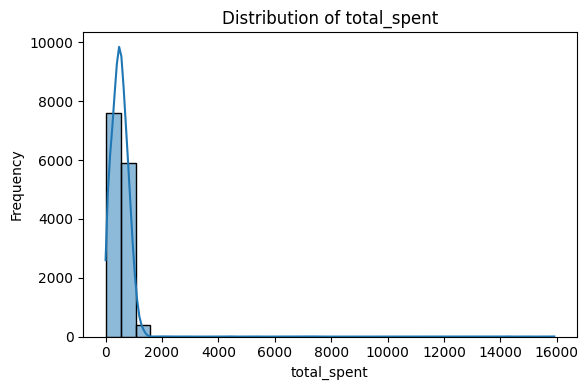

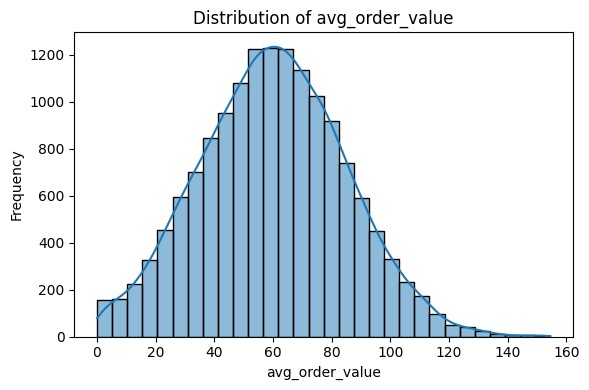

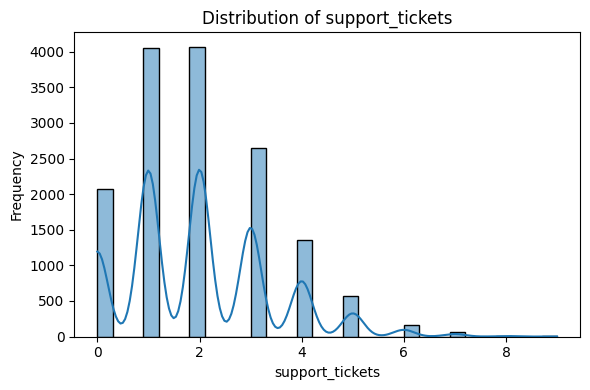

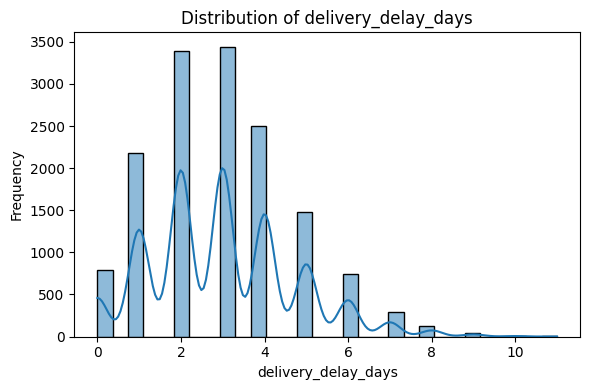

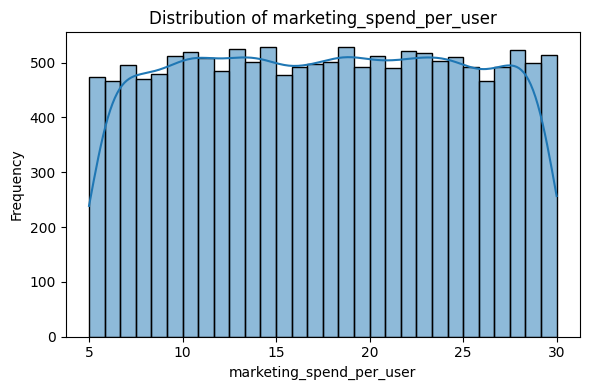

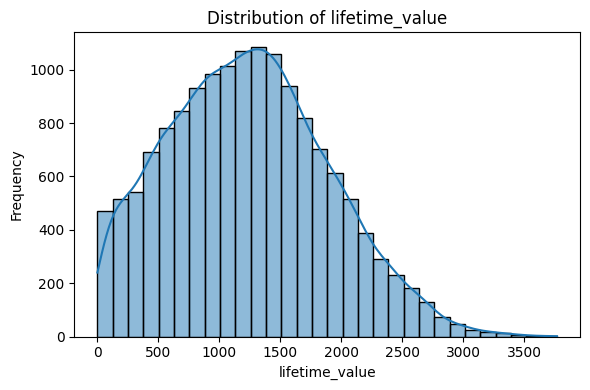

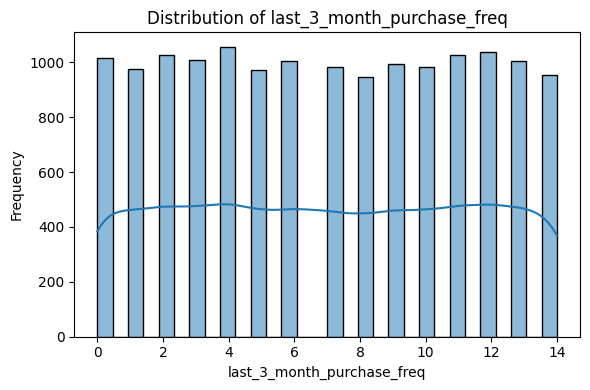

In [15]:
for col in numerical_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=data, x=col, kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

##ID Fitur : customer_id

In [16]:
id_feature = ['customer_id']

##Summary Tipe Fitur

In [17]:
feature_summary = []

for col in data.columns:
    if col in categorical_features:
        tipe = "Categorical"
    elif col in ordinal_features:
        tipe = "Ordinal"
    elif col in numerical_features:
        tipe = "Numerik"
    elif col in binary_features:
        tipe = "Biner"
    elif col in id_feature:
        tipe = "ID"
    else:
        tipe = "Target"

    feature_summary.append([col, data[col].dtype, tipe])

summary_data = pd.DataFrame(feature_summary, columns=["Feature", "Data Type", "Category"])
summary_data

,Feature,Data Type,Category
0,customer_id,int64,ID
1,gender,object,Categorical
2,age,float64,Numerik
3,country,object,Categorical
4,city,object,Categorical
5,signup_date,object,Categorical
6,last_purchase_date,object,Categorical
7,acquisition_channel,object,Categorical
8,device_type,object,Categorical
9,subscription_type,object,Categorical


Berdasarkan hasil pemetaan karakteristik data, dataset ini memiliki struktur yang kaya dan komprehensif dengan total 30 fitur yang terbagi secara variatif ke dalam 13 fitur numerik murni yang mencerminkan aktivitas perilaku serta finansial pengguna, 10 fitur kategorikal terkait informasi demografis dan transaksi, 3 fitur biner sebagai indikator aktivitas khusus, serta 2 fitur ordinal (satisfaction_score dan nps_score) yang merepresentasikan tingkat kepuasan pelanggan secara bertingkat. Keberadaan satu kolom identitas unik (customer_id) yang bersifat non-prediktif serta satu variabel target biner (churn) memperjelas bahwa dataset ini dirancang khusus untuk kasus pemodelan klasifikasi terawasi (supervised classification). Komposisi tipe data yang sangat heterogen ini mengindikasikan bahwa proyek ini membutuhkan strategi preprocessing awal yang matang, seperti penanganan data teks (encoding), konversi format tanggal, serta imputasi nilai kosong pada beberapa fitur numerik agar seluruh variabel prediktor dapat diolah secara optimal oleh algoritma machine learning.

##Cek missing value

In [18]:
# Missing values (%)
missing = data.isnull().sum()
missing_pct = (missing / len(data)) * 100

missing_data = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values(by='Missing %', ascending=False)

print(missing_data)

                            Missing Count  Missing %
coupon_code                          6133  40.886667
age                                  1200   8.000000
total_spent                          1050   7.000000
gender                                738   4.920000
satisfaction_score                    702   4.680000
customer_id                             0   0.000000
last_3_month_purchase_freq              0   0.000000
lifetime_value                          0   0.000000
marketing_spend_per_user                0   0.000000
nps_score                               0   0.000000
payment_method                          0   0.000000
delivery_delay_days                     0   0.000000
refund_requested                        0   0.000000
support_tickets                         0   0.000000
discount_used                           0   0.000000
avg_order_value                         0   0.000000
email_click_rate                        0   0.000000
email_open_rate                         0   0.

C:\Users\hanao\AppData\Local\Temp\ipykernel_4804\3300272096.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Missing %', y='index', data=missing_plot_data, palette='Reds_r')


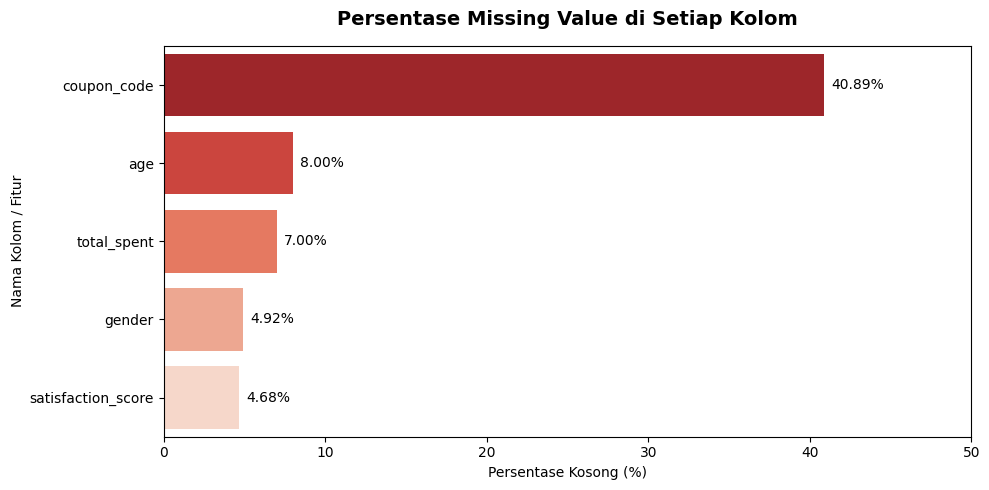

In [19]:
missing_plot_data = missing_data[missing_data['Missing Count'] > 0].reset_index()
plt.figure(figsize=(10, 5))
ax = sns.barplot(x='Missing %', y='index', data=missing_plot_data, palette='Reds_r')

for p in ax.patches:
    ax.annotate(f"{p.get_width():.2f}%",
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

plt.title('Persentase Missing Value di Setiap Kolom', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Persentase Kosong (%)')
plt.ylabel('Nama Kolom / Fitur')
plt.xlim(0, 50)
plt.tight_layout()
plt.show()

Berdasarkan analisis awal, terdapat 5 fitur dari total 30 kolom dalam dataset yang memiliki missing value dengan persentase kehilangan data bervariasi. Kolom coupon_code mencatat data kosong paling tinggi, yaitu mencapai 40,89% (6.133 data), yang dinilai wajar karena tidak semua pelanggan menggunakan kode kupon saat bertransaksi. Sementara itu, empat fitur penting lainnya memiliki tingkat missing value di bawah 10%, yaitu age (8%), total_spent (7%), gender (4,92%), dan satisfaction_score (4,68%). Keberadaan data yang hilang pada fitur-fitur krusial seperti usia, total pengeluaran, dan skor kepuasan pelanggan ini perlu menjadi catatan penting untuk ditangani menggunakan strategi imputasi (pengisian data) atau penghapusan yang tepat pada tahap Data Preparation minggu depan agar tidak mengganggu performa model prediksi churn.

##Cek Data Duplikat

In [20]:
duplicate_count = data.duplicated().sum()
print(f"Jumlah data duplikat: {duplicate_count}")

Jumlah data duplikat: 0


Berdasarkan pengecekan yang dilakukan, tidak ditemukan adanya data duplikat di dalam dataset (0 duplikat). Hal ini menunjukkan bahwa seluruh 15.000 observasi pelanggan bersifat unik, sehingga integritas data dari setiap baris tetap terjaga dan dapat langsung digunakan untuk analisis lebih lanjut tanpa memerlukan proses deduplikasi (penghapusan data ganda).

##Cek target

In [21]:
print("Unique values and counts for 'churn' (Target Variable):")
print(data['churn'].value_counts())

print("\nPercentage of each class:")
print(data['churn'].value_counts(normalize=True) * 100)

Unique values and counts for 'churn' (Target Variable):
churn
0    12702
1     2298
Name: count, dtype: int64

Percentage of each class:
churn
0    84.68
1    15.32
Name: proportion, dtype: float64


C:\Users\hanao\AppData\Local\Temp\ipykernel_4804\3252007191.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='churn', data=data, palette='viridis')


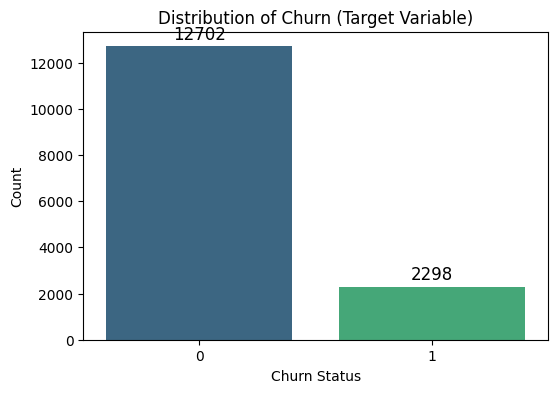

In [22]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='churn', data=data, palette='viridis')
plt.title('Distribution of Churn (Target Variable)')
plt.xlabel('Churn Status')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

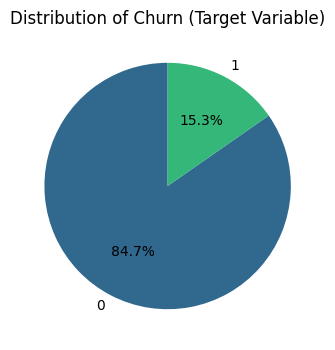

In [23]:
churn_counts = data['churn'].value_counts()

plt.figure(figsize=(6, 4))
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(churn_counts)))
plt.title('Distribution of Churn (Target Variable)')
plt.ylabel('')
plt.show()

Hasil visualisasi menunjukkan adanya ketidakseimbangan data (class imbalance) yang cukup signifikan pada variabel target. Mayoritas pelanggan masuk dalam kategori bertahan (0) sebesar 84,68% (12.702 data), sedangkan pelanggan yang churn (1) hanya sebesar 15,32% (2.298 data). Ketidakseimbangan ini perlu ditangani pada tahap pemodelan nanti, misalnya menggunakan teknik resampling atau class weight agar model tidak bias dan tetap akurat dalam memprediksi pelanggan yang berpotensi churn.

##Heatmap korelasi

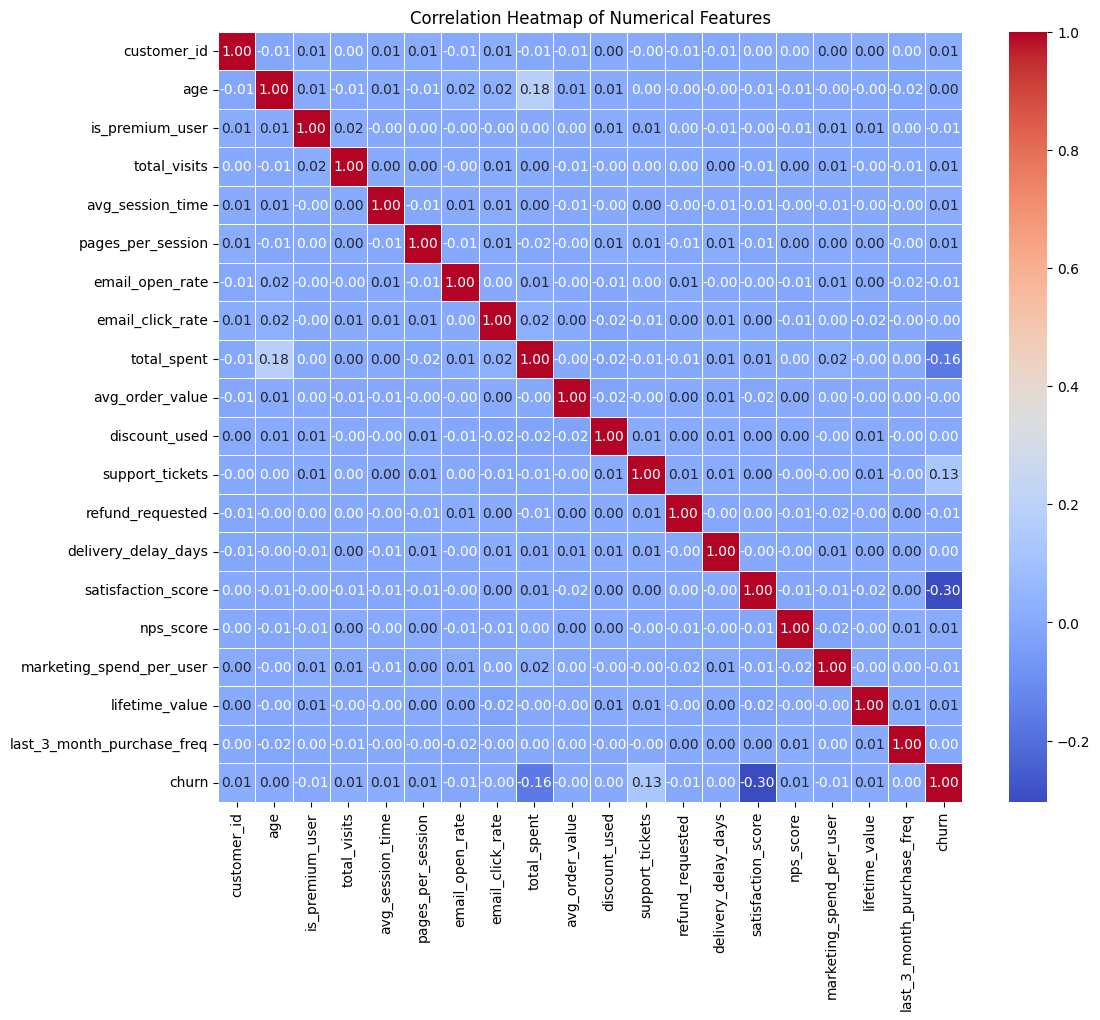

In [24]:
numerical_features = data.select_dtypes(include=['number']).columns
corr_matrix = data[numerical_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

Secara keseluruhan, mayoritas fitur numerik dalam dataset menunjukkan korelasi linear yang sangat lemah (mendekati 0,00) satu sama lain. Namun, terdapat tiga hubungan utama yang cukup menonjol terhadap variabel target (churn). Fitur satisfaction_score memiliki korelasi negatif paling kuat sebesar -0,30, mengindikasikan bahwa semakin rendah tingkat kepuasan, semakin tinggi potensi pelanggan untuk churn. Sebaliknya, fitur support_tickets menunjukkan korelasi positif sebesar 0,13, yang berarti banyaknya keluhan pelanggan berbanding lurus dengan risiko churn. Sementara itu, fitur total_spent memiliki korelasi negatif sebesar -0,16, menunjukkan bahwa pelanggan dengan pengeluaran tinggi cenderung lebih loyal dan bertahan.

#Soal Kedua : 2. Direct Modeling

##Small preprocesing for Technical Adjustment (missing value handling & encoding)

In [25]:
data['coupon_code'] = data['coupon_code'].fillna('No_Coupon')
data['gender'] = data['gender'].fillna('Other')

median_satisfaction_score = data['satisfaction_score'].median()
data['satisfaction_score'] = data['satisfaction_score'].fillna(median_satisfaction_score)

mean_age = data['age'].mean()
data['age'] = data['age'].fillna(mean_age)

median_total_spent = data['total_spent'].median()
data['total_spent'] = data['total_spent'].fillna(median_total_spent)

In [26]:
print("Missing values after imputation:")
print(data[['coupon_code', 'gender', 'satisfaction_score', 'age', 'total_spent']].isnull().sum())

Missing values after imputation:
coupon_code           0
gender                0
satisfaction_score    0
age                   0
total_spent           0
dtype: int64


In [27]:
from sklearn.preprocessing import OneHotEncoder
categorical_features_to_encode = [
    'gender', 'country', 'city', 'acquisition_channel',
    'device_type', 'subscription_type', 'coupon_code', 'payment_method'
]

data = pd.get_dummies(data, columns=categorical_features_to_encode, drop_first=True)
print("Semua fitur kategorikal berhasil di-One-Hot Encode!")

Semua fitur kategorikal berhasil di-One-Hot Encode!


In [28]:
# FEATURE ENGINEERING UNTUK KOLOM TANGGAL
data['signup_date'] = pd.to_datetime(data['signup_date'])
data['last_purchase_date'] = pd.to_datetime(data['last_purchase_date'])

data['days_to_last_purchase'] = (data['last_purchase_date'] - data['signup_date']).dt.days

data['signup_year'] = data['signup_date'].dt.year
data['signup_month'] = data['signup_date'].dt.month

data = data.drop(columns=['signup_date', 'last_purchase_date'])

print(data[['days_to_last_purchase', 'signup_year', 'signup_month']].head())

   days_to_last_purchase  signup_year  signup_month
0                    966         2022             5
1                    -40         2024             6
2                    249         2023             8
3                   -253         2024             1
4                    261         2023             7


In [29]:
data.head()

,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,...,coupon_code_No_Coupon,coupon_code_REF10,coupon_code_SALE15,payment_method_Card,payment_method_PayPal,payment_method_SEPA,payment_method_UPI,days_to_last_purchase,signup_year,signup_month
0,10001,52.0,1,7,13.903745,5.415164,0.67,0.26,559.524958,65.246704,...,False,False,False,False,False,False,True,966,2022,5
1,10002,35.0,0,19,5.112528,5.352441,0.70,0.37,356.491344,48.473887,...,False,False,False,False,False,False,False,-40,2024,6
2,10003,27.0,1,18,9.742749,3.594719,0.47,0.44,689.332196,77.815371,...,True,False,False,False,False,False,True,249,2023,8
3,10004,36.0,1,16,9.642654,2.949531,0.58,0.37,445.429636,71.712192,...,True,False,False,False,True,False,False,-253,2024,1
4,10005,29.0,0,12,7.791291,2.405539,0.05,0.16,686.286022,44.990246,...,True,False,False,False,False,False,False,261,2023,7


In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 49 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   customer_id                       15000 non-null  int64  
 1   age                               15000 non-null  float64
 2   is_premium_user                   15000 non-null  int64  
 3   total_visits                      15000 non-null  int64  
 4   avg_session_time                  15000 non-null  float64
 5   pages_per_session                 15000 non-null  float64
 6   email_open_rate                   15000 non-null  float64
 7   email_click_rate                  15000 non-null  float64
 8   total_spent                       15000 non-null  float64
 9   avg_order_value                   15000 non-null  float64
 10  discount_used                     15000 non-null  int64  
 11  support_tickets                   15000 non-null  int64  
 12  refu

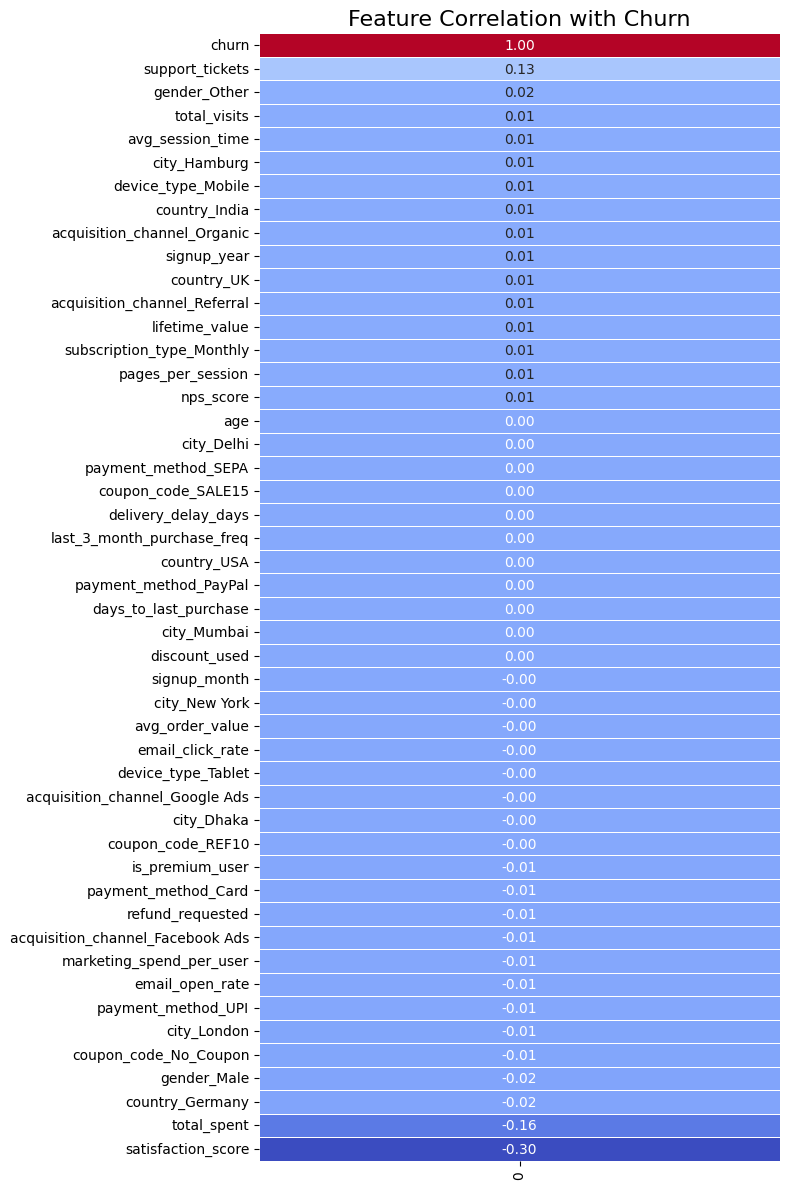

In [31]:
correlation_with_churn = data.drop(columns=['customer_id']).corrwith(data['churn']).sort_values(ascending=False)

plt.figure(figsize=(8, 12))
sns.heatmap(correlation_with_churn.to_frame(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar=False)
plt.title('Feature Correlation with Churn', fontsize=16)
plt.yticks(rotation=0)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Di proyek ini, aku pakai tiga model buat baseline, yaitu Logistic Regression, Random Forest, dan Voting Classifier (gabungan dari Logistic Regression, Random Forest, plus XGBoost). Nah, masalahnya algoritma-algoritma ini tuh gabisa sama data teks (categorical) dan kolom yang missing values.

Makanya, di awal aku lakuin One Hot Encoding buat ngubah fitur-fitur kategori jadi angka. Langkah ini penting banget dibanding Label Encoding supaya model konvensional kayak Logistic Regression gak terjebak bias urutan kasta angka. Khusus buat kolom tanggal (signup_date dan last_purchase_date), jelas gak bisa langsung di-encode begitu aja karena variasi datanya banyak banget dan aku butuh makna waktunya. Jadi, aku mutusin buat pakai Feature Engineering biar informasi tanggalnya bisa diekstrak jadi rentang hari dan data musiman numerik yang jauh lebih berguna buat model.

Nah, karena ada missing value yang persentasenya sampai 40% di kolom kupon, daripada baris data itu di-drop atau dihapus, yang malah bikin rugi kehilangan hampir separuh informasi penting, aku milih buat ngelakuin Data Imputation. Untuk data teks, aku isi dengan kategori baru kayak 'No_Coupon' dan 'Other', sedangkan data numerik diisi menggunakan nilai mean untuk variabel yang simetris kayak usia, serta median untuk variabel yang rentan outlier kayak pengeluaran pelanggan. Cara ini jauh lebih aman biar data ini tetep utuh di 15.000 baris  dan performa model pas prediksi gak jadi bias

Perlu dicatat kalau semua langkah pengisian data kosong dan encoding di atas baru sebatas technical adjustment minimum ya. Tujuannya murni supaya data ini lolos dari error saat dimasukkan ke Direct Modeling. Eksperimen preprocessing yang lebih mendalam, pembersihan data kotor, ataupun seleksi fitur yang komprehensif baru akan aku bahas secara total nanti di soal ketiga ya

##Import library modeling

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
!pip install xgboost
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


##Deklarasi X dan Y

In [33]:
y = data['churn']
X = data.drop(columns=['churn'])

##Split dataset menjadi train dan test

In [34]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print(f"Total data      : {len(X)}")
print(f"Train data      : {len(X_train)} ({len(X_train)/len(X)*100:.2f}%)")
print(f"Test data       : {len(X_test)} ({len(X_test)/len(X)*100:.2f}%)")

Total data      : 15000
Train data      : 12000 (80.00%)
Test data       : 3000 (20.00%)


##Modeling

=== Logistic Regression Evaluation ===

-- Accuracy --
Train: 0.8446
Test : 0.8523

-- F1 Score (Macro) --
Train: 0.5750
Test : 0.5843

-- Classification Report (Train) --
              precision    recall  f1-score   support

           0       0.86      0.97      0.91     10146
           1       0.49      0.16      0.24      1854

    accuracy                           0.84     12000
   macro avg       0.68      0.56      0.58     12000
weighted avg       0.81      0.84      0.81     12000


-- Classification Report (Test) --
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      2556
           1       0.50      0.17      0.25       444

    accuracy                           0.85      3000
   macro avg       0.69      0.57      0.58      3000
weighted avg       0.82      0.85      0.82      3000



c:\Users\hanao\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


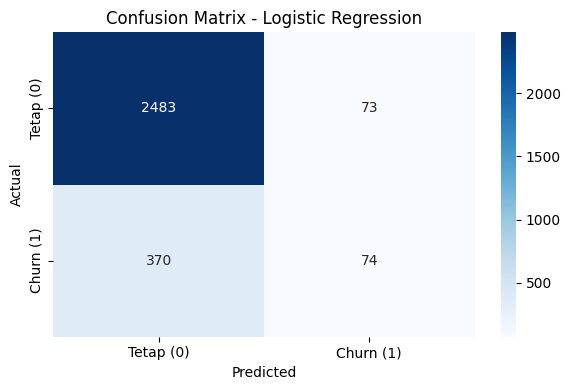

In [35]:
# MODEL 1: LOGISTIC REGRESSION
lr_model = LogisticRegression(random_state=42, max_iter=1000)

# Train
lr_model.fit(X_train, y_train)
# Predict
y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)

# Evaluation
print("=== Logistic Regression Evaluation ===")
print("\n-- Accuracy --")
print(f"Train: {accuracy_score(y_train, y_train_pred_lr):.4f}")
print(f"Test : {accuracy_score(y_test, y_test_pred_lr):.4f}")
print("\n-- F1 Score (Macro) --")
print(f"Train: {f1_score(y_train, y_train_pred_lr, average='macro'):.4f}")
print(f"Test : {f1_score(y_test, y_test_pred_lr, average='macro'):.4f}")

print("\n-- Classification Report (Train) --")
print(classification_report(y_train, y_train_pred_lr))
print("\n-- Classification Report (Test) --")
print(classification_report(y_test, y_test_pred_lr))

# CM
cm_lr = confusion_matrix(y_test, y_test_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tetap (0)', 'Churn (1)'],
            yticklabels=['Tetap (0)', 'Churn (1)'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

=== Random Forest Evaluation ===

-- Accuracy --
Train: 1.0000
Test : 0.8483

-- F1 Score (Macro) --
Train: 1.0000
Test : 0.5555

-- Classification Report (Train) --
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10146
           1       1.00      1.00      1.00      1854

    accuracy                           1.00     12000
   macro avg       1.00      1.00      1.00     12000
weighted avg       1.00      1.00      1.00     12000


-- Classification Report (Test) --
              precision    recall  f1-score   support

           0       0.86      0.97      0.92      2556
           1       0.45      0.12      0.19       444

    accuracy                           0.85      3000
   macro avg       0.66      0.55      0.56      3000
weighted avg       0.80      0.85      0.81      3000



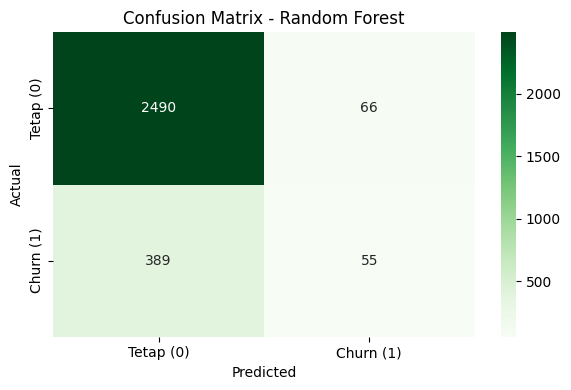

In [36]:
# MODEL 2: RANDOM FOREST CLASSIFIER
rf_model = RandomForestClassifier(random_state=42, n_estimators=1000)

# Train
rf_model.fit(X_train, y_train)
# Predict
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Evaluation
print("=== Random Forest Evaluation ===")
print("\n-- Accuracy --")
print(f"Train: {accuracy_score(y_train, y_train_pred_rf):.4f}")
print(f"Test : {accuracy_score(y_test, y_test_pred_rf):.4f}")
print("\n-- F1 Score (Macro) --")
print(f"Train: {f1_score(y_train, y_train_pred_rf, average='macro'):.4f}")
print(f"Test : {f1_score(y_test, y_test_pred_rf, average='macro'):.4f}")

print("\n-- Classification Report (Train) --")
print(classification_report(y_train, y_train_pred_rf))
print("\n-- Classification Report (Test) --")
print(classification_report(y_test, y_test_pred_rf))

# CM
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Tetap (0)', 'Churn (1)'],
            yticklabels=['Tetap (0)', 'Churn (1)'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

c:\Users\hanao\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Ensemble Voting Evaluation ===

-- Accuracy --
Train: 0.9997
Test : 0.8593

-- F1 Score (Macro) --
Train: 0.9994
Test : 0.6320

-- Classification Report (Train) --
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10146
           1       1.00      1.00      1.00      1854

    accuracy                           1.00     12000
   macro avg       1.00      1.00      1.00     12000
weighted avg       1.00      1.00      1.00     12000


-- Classification Report (Test) --
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      2556
           1       0.56      0.25      0.34       444

    accuracy                           0.86      3000
   macro avg       0.72      0.61      0.63      3000
weighted avg       0.83      0.86      0.84      3000



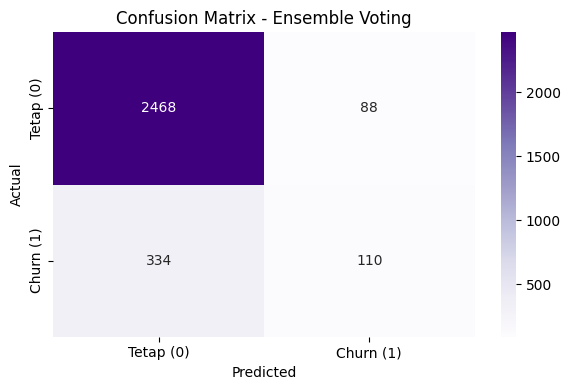

In [37]:
lr_base = LogisticRegression(random_state=42, max_iter=1000)
rf_base = RandomForestClassifier(random_state=42, n_estimators=1000)
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')

voting_model = VotingClassifier(
    estimators=[
        ('lr', lr_base),
        ('rf', rf_base),
        ('xgb', xgb_base)
    ],
    voting='soft'
)

# Train
voting_model.fit(X_train, y_train)

# Predict
y_train_pred_vt = voting_model.predict(X_train)
y_test_pred_vt = voting_model.predict(X_test)

# Evaluation
print("=== Ensemble Voting Evaluation ===")
print("\n-- Accuracy --")
print(f"Train: {accuracy_score(y_train, y_train_pred_vt):.4f}")
print(f"Test : {accuracy_score(y_test, y_test_pred_vt):.4f}")
print("\n-- F1 Score (Macro) --")
print(f"Train: {f1_score(y_train, y_train_pred_vt, average='macro'):.4f}")
print(f"Test : {f1_score(y_test, y_test_pred_vt, average='macro'):.4f}")

print("\n-- Classification Report (Train) --")
print(classification_report(y_train, y_train_pred_vt))
print("\n-- Classification Report (Test) --")
print(classification_report(y_test, y_test_pred_vt))

# CM Diagram
cm_vt = confusion_matrix(y_test, y_test_pred_vt)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_vt, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Tetap (0)', 'Churn (1)'],
            yticklabels=['Tetap (0)', 'Churn (1)'])
plt.title('Confusion Matrix - Ensemble Voting')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [38]:
summary_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'Ensemble Voting'],
    'Accuracy': [0.8523, 0.8483, 0.8593],
    'F1-Score (Macro)': [0.5843, 0.5555, 0.6320],
    'Precision (Churn/1)': [0.5000, 0.4500, 0.5600], 
    'Recall (Churn/1)': [0.1700, 0.1200, 0.2500]
}

data_summary = pd.DataFrame(summary_data)
print(data_summary.to_string(index=False))

              Model  Accuracy  F1-Score (Macro)  Precision (Churn/1)  Recall (Churn/1)
Logistic Regression    0.8523            0.5843                 0.50              0.17
      Random Forest    0.8483            0.5555                 0.45              0.12
    Ensemble Voting    0.8593            0.6320                 0.56              0.25


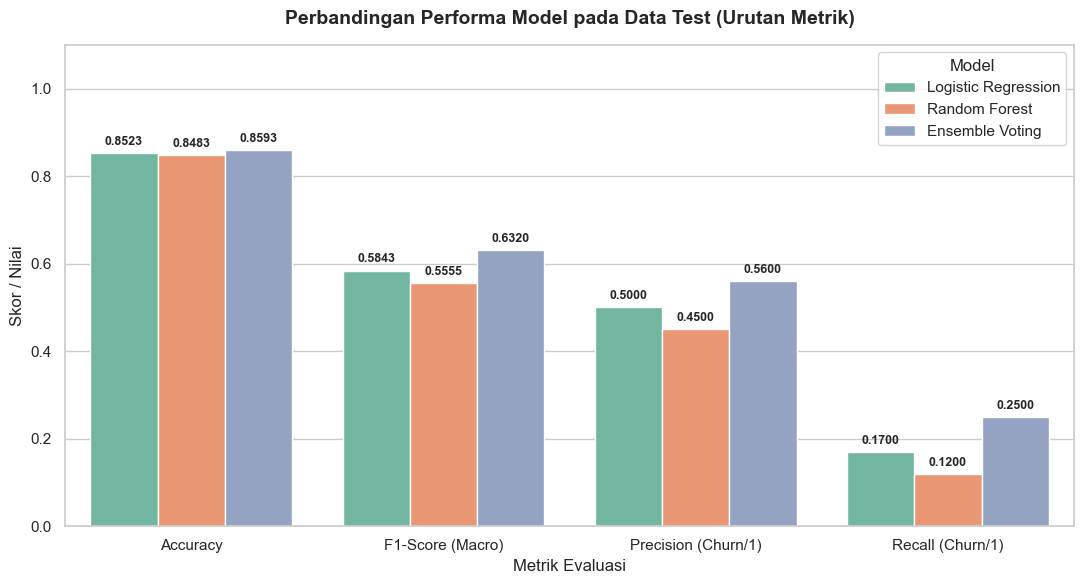

In [39]:
data_melted = pd.melt(data_summary, id_vars='Model', var_name='Metrik', value_name='Skor')

plt.figure(figsize=(11, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x='Metrik', y='Skor', hue='Model', data=data_melted, palette='Set2')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.4f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 8),
                    textcoords='offset points',
                    fontsize=9, fontweight='bold')

plt.title('Perbandingan Performa Model pada Data Test (Urutan Metrik)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Skor / Nilai', fontsize=12)
plt.xlabel('Metrik Evaluasi', fontsize=12)
plt.ylim(0, 1.1)
plt.legend(title='Model', loc='upper right')
plt.tight_layout()
plt.show()

Berdasarkan hasil pengujian skenario Direct Modeling, ketiga model dasar (baseline) mampu menghasilkan tingkat akurasi pengujian (Test Accuracy) yang stabil di kisaran 85% akibat dominasi kelas mayoritas (pelanggan bertahan) di dalam dataset. Namun, perbedaan performa yang sangat kontras terlihat pada kemampuan model dalam mendeteksi kelas target (1 / Churn) , di mana model Random Forest mengalami indikasi overfitting yang ekstrem dengan nilai akurasi train sempurna (1.0000) tetapi mencatat nilai Recall test terendah sebesar 0.12 akibat terjebak menghafal kolom identitas non-prediktif seperti customer_id. Di sisi lain, model Logistic Regression menunjukkan performa yang jauh lebih konsisten antara data latihan dan pengujian (Test Accuracy: 0.8523 dan Test F1-Macro: 0.5843), sementara Ensemble Voting keluar sebagai model dasar terbaik dengan menghasilkan performa paling optimal di seluruh metrik pengujian, termasuk capaian akurasi tertinggi (0.8593), peningkatan F1-Score Macro (0.6320), serta nilai Recall target churn yang paling sensitif (0.25).